Notes prèvies:

Després d'haver considerat els comentaris de la retroacció de l'spint 6, hem decidit seguir endavant amb l'aplicació del PCA. Les suggerències aportades són molt útils i creiem que, efectivament, ajudarien a reduir la dimensionalitat d'una forma més lògica i natural, podent interpretar millor els resultats. No obstant, donat que això suposaria modificar una entrega ja revisada i aprovada, hem decidit seguir endavant amb el PCA. A més a més l'aplicació del PCA comporta una capa extra d'abstracció que ens ajudarà a comprendre amb més profunditat l'aplicació d'aquest tipus de tècniques i la seva interpretació.

# Entrenament dels models

A partir de les dades sortints de l'sprint 6, on han estat preparades per a l'entrenament dels models, en aquest notebook es realitzaran les següents tasques:
- Visualització dels components principals sortints del PCA
- Entrenament dels models i obtenció dels resultats i les mètriques de rendiment de cada model
- Anàlisi comparativa dels resultats obtinguts pels diferents models i relació amb els objectius de negoci
- Conclusions

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import recall_score, f1_score, auc, roc_curve, precision_score, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from scipy.stats import uniform
import joblib
import warnings
warnings.filterwarnings('ignore')

## Visualització dels components principals sortints del PCA

A continuació mostrem un mapa de calor amb els pesos de cada variable en els components principals sortints del PCA. Aquesta informació ens permetrà entendre quines variables són més importants per a cada component i per tant, per a cada model.

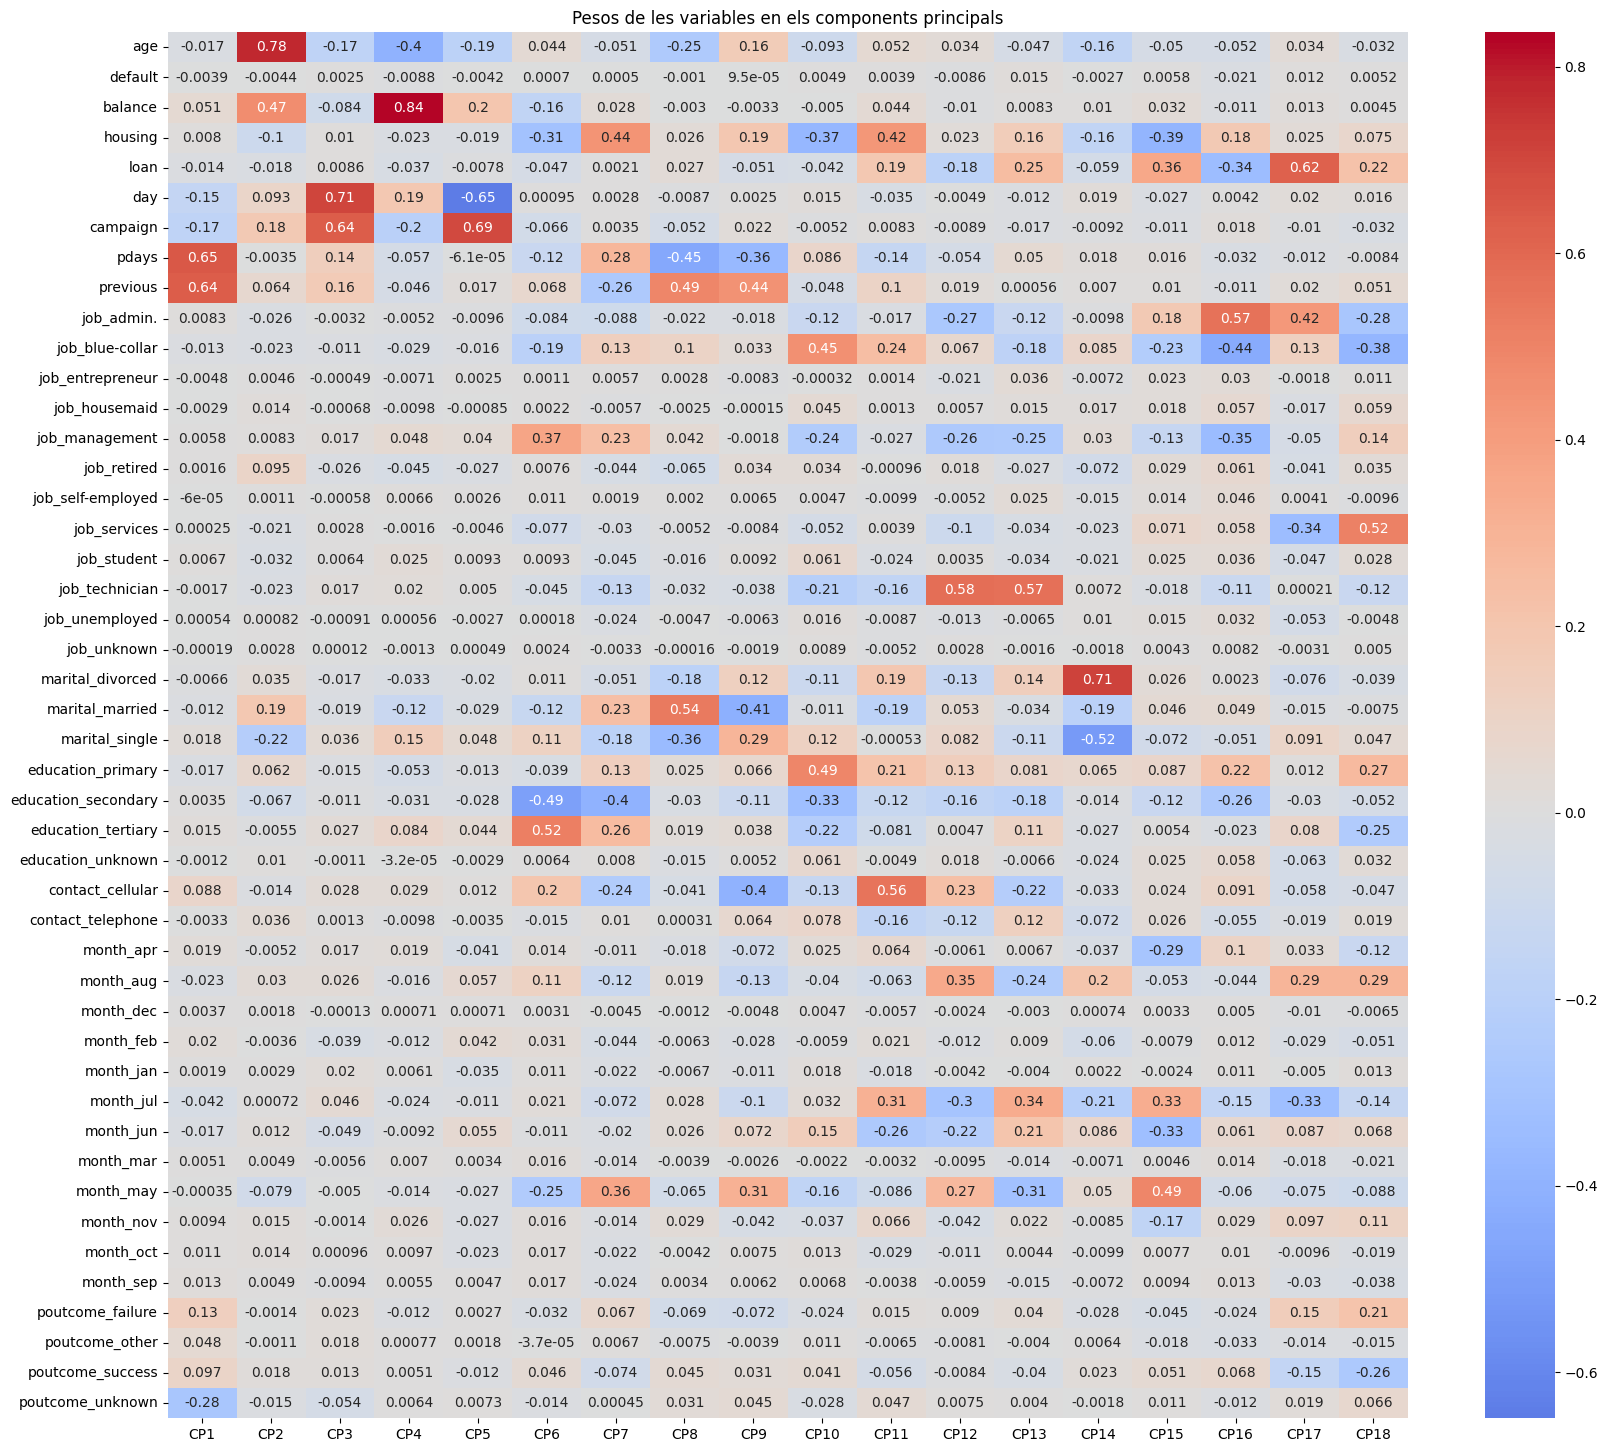

Aquesta tasca s'ha realitzat com a extra al notebook entregat a l'sprint 6. En cas de voler revisar el codi, es pot trobar al següent enllaç: [preparacio_dades_entrenament.ipynb](https://github.com/adriahf/Projecte-Machine-Learning/blob/main/Sprint%206/preparacio_dades_entrenament.ipynb)

A l'apartat de l'anàlisi comparativa es farà referència a aquesta informació per a interpretar els resultats obtinguts pels diferents models.

## Entrenament dels models i obtenció dels resultats i les mètriques de rendiment de cada model

En aquesta secció explorarem l'aplicació de 3 algoritmes diferents: 
- Regressió Logística
- Random Forest Classifier
- Gradient Boosting Machine
 
Tots ells seran entrenats i avaluats utilitzant les dades preparades en l'sprint 6. En tots els casos s'aplicarà una **optimització d'hiperparàmetres**, que permetrà millorar el rendiment dels models, i una **validació creuada** (cross validation), que ens permetrà saber si estem sobreajustant els models.

Les mètriques de rendiment que utilitzarem els descriuen a continuació:

- **Recall**: La proporció de positius reals que s'han identificat correctament. És a dir, la capacitat del classificador per trobar tots els casos positius. És important perquè volem minimitzar els falsos negatius (clients que subscriurien un dipòsit però el model prediu que no ho faran). Un Recall alt indica que el model està capturant la majoria de les oportunitats de subscripció.
- **Precision (Precisió)**: La proporció de positius identificats correctament respecte a tots els positius identificats pel model. És important perquè volem minimitzar els falsos positius (clients que el model prediu que subscriuran un dipòsit però no ho fan). Una Precisió alta significa que quan el model prediu un "sí", és molt probable que el client realment subscrigui un dipòsit.
- **F1 Score**: La mitjana harmònica de Recall i Precisió. Combina les dues mètriques en una sola, cosa que és especialment útil quan les classes estan desbalancejades (per exemple, molts més "no" que "sí"). Un F1-Score alt indica que el model té un bon equilibri entre identificar correctament els positius (Recall) i no generar massa falsos positius (Precisió).
- **AUC-ROC**: L'AUC-ROC mesura la capacitat del model per distingir entre les dues classes (en aquest cas, "sí" i "no"). Es basa en la corba ROC, que representa la Taxa de Vertaders Positius (TPR) contra la Taxa de Falsos Positius (FPR) per diferents llindars de classificació. Un AUC proper a 1 indica que el model té una excel·lent capacitat de separació entre les classes. Un AUC de 0.5 suggereix que el model no és millor que l'aleatorietat. És útil per avaluar com de bé el model pot discriminar entre clients que subscriuran i els que no, independentment del llindar de classificació.
- **Accuracy (Exactitud)**: L'Accuracy mesura la proporció de prediccions correctes (tant vertaders positius com vertaders negatius) sobre el total de prediccions. Proporciona una visió general de l'efectivitat del model en termes de classificació correcta de totes les instàncies, tant positives com negatives. Un Accuracy alt indica que el model està fent prediccions correctes en la majoria dels casos. És útil quan les classes estan balancejades i es vol una mesura general del rendiment del model.
- **Confusion Matrix (Matriu de Confusió)**: La matriu de confusió mostra el nombre de vertaders positius, falsos positius, vertaders negatius i falsos negatius. És útil per entendre com el model està classificant les instàncies i per identificar els errors més comuns.

A més a més, a la següent secció també analitzarem la importància de les variables en cada model per entendre quines característiques són més rellevants per a la predicció de subscripcions a dipòsits.

In [2]:
# carreguem les dades sortints de l'sprint 6
X_train = pd.read_csv('dades/X_train_sprint6.csv')
X_test = pd.read_csv('dades/X_test_sprint6.csv')
y_train = pd.read_csv('dades/y_train_sprint6.csv')
y_test = pd.read_csv('dades/y_test_sprint6.csv')

Definim un parell de funcions de visualització de resultats

In [3]:
# calcular i visualitzar la corba ROC
def plot_roc_curve(y_test, y_pred_proba, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)  # Calcular FPR i TPR
    roc_auc = auc(fpr, tpr)  # Calcular l'àrea sota la corba (AUC)

    # visualitzar la corba ROC
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Línia de referència (aleatorietat)
    plt.xlabel('Taxa de Falsos Positius (FPR)')
    plt.ylabel('Taxa de Vertaders Positius (TPR)')
    plt.title('Corba ROC')
    plt.legend(loc='lower right')
    plt.grid(linestyle='--')
    plt.show()

# visualitzar la matriu de confusió
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)  # Calcula la matriu de confusió
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'])
    plt.title(f'Matriu de Confusió - {model_name}')
    plt.xlabel('Predicció')
    plt.ylabel('Real')
    plt.show()

### Regressió Logística

Un algoritme de regressió logística és un mètode d'aprenentatge supervisat utilitzat per a classificació binària, que prediu la probabilitat que una instància pertanyi a una de dues classes, mitjançant una funció logística (sigmoide) que modela la relació entre les variables independents i la variable dependent categòrica.

Millors hiperparàmetres: {'C': 0.10409127568994281, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Rendiment mitjà per a la mètrica Recall (5-fold cross-validation): 0.67 (± 0.01)
Recall: 0.67
F1: 0.65
Precisió: 0.64
Accuracy: 0.67


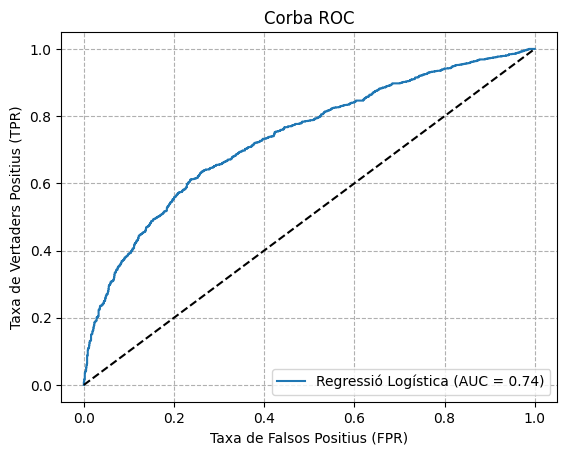

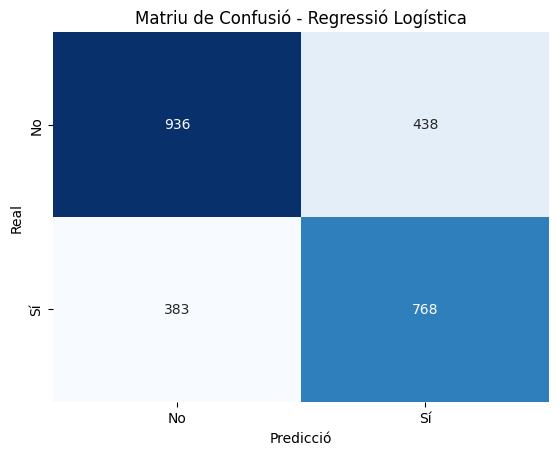

In [ ]:
# apliquem un algortme de regressió logística
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# definim el model de regressió logística
model_lr = LogisticRegression(random_state=42)

# definim la distribució d'hiperparàmetres per a Random Search
param_dist = {
    'C': loguniform(1e-3, 100),         # prova valors de C en una escala logarítmica
    'penalty': ['l1', 'l2'],            # prova regularització L1 i L2
    'solver': ['liblinear', 'lbfgs'],   # prova diferents algoritmes
    'class_weight': [None, 'balanced']  # prova amb i sense balanceig de classes
}

# fem la cerca aleatòria amb validació creuada
random_search = RandomizedSearchCV(
    model_lr, 
    param_distributions=param_dist, 
    n_iter=500,       # nombre de combinacions aleatòries a provar
    cv=5,             # validació creuada de 5 folds
    scoring='recall', # utilitzem recall com a mètrica
    random_state=42
)
random_search.fit(X_train, y_train.values.ravel())

# mostrem els millors hiperparàmetres
print("Millors hiperparàmetres:", random_search.best_params_)

# entrenem el model final amb els millors hiperparàmetres
model_lr_final = random_search.best_estimator_

# validació creuada amb el model final
scores_lr = cross_val_score(model_lr_final, X_train, y_train.values.ravel(), cv=5, scoring='recall')
print(f'Rendiment mitjà per a la mètrica Recall (5-fold cross-validation): {scores_lr.mean():.2f} (± {scores_lr.std():.2f})')

# prediccions de classes (0 o 1)
y_pred = model_lr_final.predict(X_test)

# mètriques de rendiment
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f'Recall: {recall:.2f}')
print(f'F1: {f1:.2f}')
print(f'Precisió: {precision:.2f}')
print(f'Accuracy: {accuracy:.2f}')

# prediccions de probabilitats per a la corba ROC
y_pred_proba_lr = model_lr_final.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_pred_proba_lr, 'Regressió Logística')

# prediccions de classes per a la matriu de confusió
y_pred_lr = model_lr_final.predict(X_test)
plot_confusion_matrix(y_test, y_pred_lr, 'Regressió Logística')

In [36]:
# analitzem la importància de les variables en els resultats de la regressió logística

# obtenim els coeficients
coeficients = model_lr_final.coef_[0]

# creem un DataFrame per visualitzar les importàncies
feature_importance_lr = pd.DataFrame({
    'feature': X_train.columns,
    'importance': coeficients
})

# ordenem per importància absoluta (valor absolut dels coeficients)
feature_importance_lr['importance'] = feature_importance_lr['importance']
feature_importance_lr = feature_importance_lr.sort_values(by='importance', ascending=False)

print("Importància de les característiques (Regressió Logística):")
print(feature_importance_lr)

Importància de les característiques (Regressió Logística):
   feature  importance
5        5    0.528006
0        0    0.362153
15      15    0.333459
3        3    0.265685
9        9    0.199464
1        1    0.097378
11      11    0.019547
4        4    0.000000
10      10    0.000000
13      13    0.000000
7        7   -0.051026
8        8   -0.057206
14      14   -0.057303
2        2   -0.131323
12      12   -0.331993
16      16   -0.531469
6        6   -0.695402
17      17   -0.943221


### Random Forest Classifier

Random Forest és un mètode d'aprenentatge supervisat basat en l'aprenentatge per conjunts (ensemble learning) que crea múltiples arbres de decisió i combina les seves prediccions per a millorar la precisió i evitar el sobreajustament.

Millors hiperparàmetres: {'bootstrap': False, 'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'min_samples_split': 18, 'n_estimators': 153}
Rendiment mitjà per a la mètrica Recall (5-fold cross-validation): 0.64 (± 0.01)
Recall: 0.64
F1: 0.66
Precisió: 0.68
Accuracy: 0.70


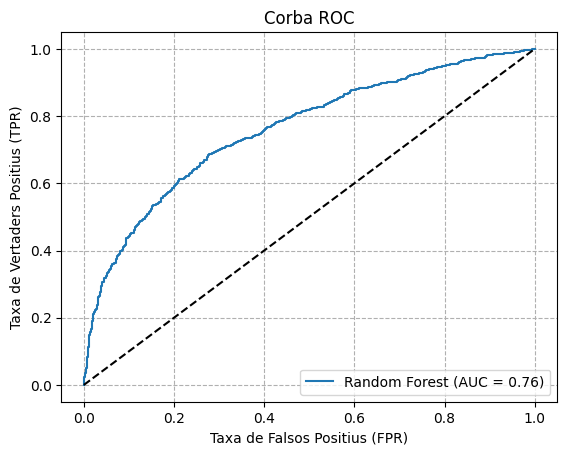

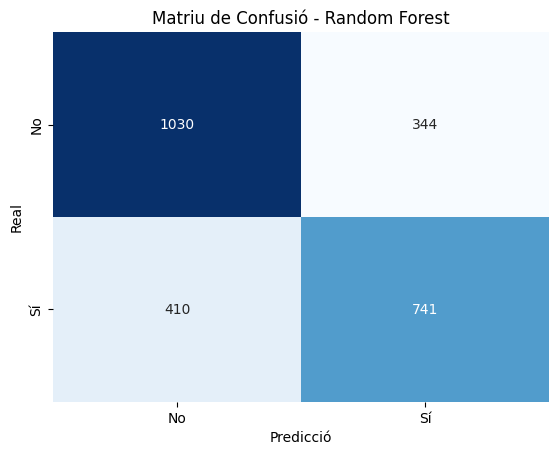

In [30]:
# apliquem un algoritme Random Forest Classifier
from scipy.stats import randint

# definim el model de Random Forest
model_rf = RandomForestClassifier(random_state=42)

# definim la distribució d'hiperparàmetres per a Random Search
param_dist = {
    'n_estimators': randint(50, 200),       # nombre d'arbres (entre 50 i 200)
    'max_depth': [None, 10, 20, 30],        # profunditat màxima dels arbres
    'min_samples_split': randint(2, 20),    # mínim de mostres per dividir un node
    'min_samples_leaf': randint(1, 20),     # mínim de mostres en una fulla
    'max_features': ['sqrt', 'log2'],       # nombre de característiques a considerar
    'bootstrap': [True, False],             # utilitzar mostreig bootstrap
    'class_weight': [None, 'balanced']      # pes de les classes
}

# fem la cerca aleatòria amb validació creuada
random_search = RandomizedSearchCV(
    model_rf, 
    param_distributions=param_dist, 
    n_iter=50,          # nombre de combinacions aleatòries a provar
    cv=5,               # validació creuada de 5 folds
    scoring='recall',   # utilitzem recall com a mètrica
    random_state=42
)
random_search.fit(X_train, y_train.values.ravel())

# mostrem els millors hiperparàmetres
print("Millors hiperparàmetres:", random_search.best_params_)

# entrenem el model final amb els millors hiperparàmetres
model_rf_final = random_search.best_estimator_

# validació creuada amb el model final
scores_rf = cross_val_score(model_rf_final, X_train, y_train.values.ravel(), cv=5, scoring='recall')
print(f'Rendiment mitjà per a la mètrica Recall (5-fold cross-validation): {scores_rf.mean():.2f} (± {scores_rf.std():.2f})')

# prediccions de classes (0 o 1)
y_pred = model_rf_final.predict(X_test)

# mètriques de rendiment
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f'Recall: {recall:.2f}')
print(f'F1: {f1:.2f}')
print(f'Precisió: {precision:.2f}')
print(f'Accuracy: {accuracy:.2f}')

# prediccions de probabilitats per a la corba ROC
y_pred_proba_rf = model_rf_final.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_pred_proba_rf, 'Random Forest')

# prediccions de classes per a la matriu de confusió
y_pred_rf = model_rf_final.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')

In [35]:
# analitzem la importància de les variables en els resultats del random forest classifier

# obtenim les importàncies de les característiques
importancies_rf = model_rf_final.feature_importances_

# creem un DataFrame per visualitzar les importàncies
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importancies_rf
})

# ordenem per importància
feature_importance_rf = feature_importance_rf.sort_values(by='importance', ascending=False)

print("Importància de les característiques (Random Forest Classifier):")
print(feature_importance_rf)

Importància de les característiques (Random Forest Classifier):
   feature  importance
0        0    0.156824
6        6    0.080752
5        5    0.078066
17      17    0.069061
3        3    0.060718
1        1    0.053110
7        7    0.051940
10      10    0.049816
16      16    0.049415
8        8    0.048734
9        9    0.042586
12      12    0.041105
14      14    0.038539
11      11    0.038482
4        4    0.037057
15      15    0.035998
2        2    0.035660
13      13    0.032137


### Gradient Boosting Machine

Gradient Boosting és un altre mètode d'aprenentatge per conjunts que construeix un model predictiu en forma de conjunt de models predictius més febles (generalment arbres de decisió) i els optimitza seqüencialment per a minimitzar l'error de pèrdua.

Millors hiperparàmetres: {'learning_rate': 0.14910321728522552, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 14, 'n_estimators': 192, 'subsample': 0.9511102277086098}
Rendiment mitjà per a la mètrica Recall (5-fold cross-validation): 0.61 (± 0.01)
Recall: 0.61
F1: 0.64
Precisió: 0.68
Accuracy: 0.69


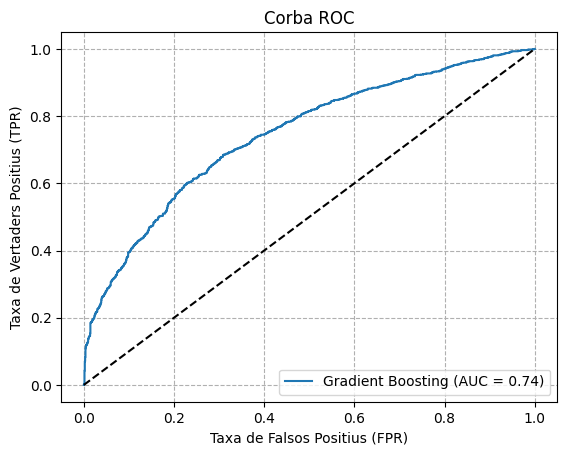

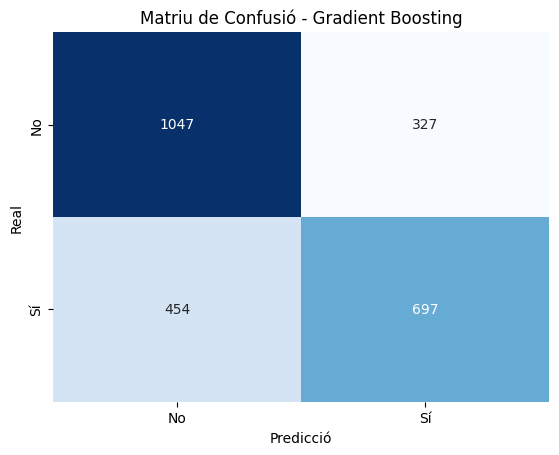

In [33]:
# apliquem un algoritme de Gradient Boosting Classifier

# definim el model de Gradient Boosting
model_gb = GradientBoostingClassifier(random_state=42)

# definim la distribució d'hiperparàmetres per a Random Search
param_dist = {
    'n_estimators': randint(50, 200),    # nombre d'arbres (entre 50 i 200)
    'learning_rate': uniform(0.01, 0.2), # taxa d'aprenentatge (entre 0.01 i 0.2)
    'max_depth': randint(3, 10),         # profunditat màxima dels arbres (entre 3 i 10)
    'min_samples_split': randint(2, 20), # mínim de mostres per dividir un node (entre 2 i 20)
    'min_samples_leaf': randint(1, 20),  # mínim de mostres en una fulla (entre 1 i 20)
    'max_features': ['sqrt', 'log2'],    # nombre de característiques a considerar
    'subsample': uniform(0.8, 0.2)       # fracció de mostres utilitzades per a cada arbre (entre 0.8 i 1.0)
}

# fem la cerca aleatòria amb validació creuada
random_search = RandomizedSearchCV(
    model_gb, 
    param_distributions=param_dist, 
    n_iter=50,          # nombre de combinacions aleatòries a provar
    cv=5,               # validació creuada de 5 folds
    scoring='recall',   # utilitzem recall com a mètrica
    random_state=42
)
random_search.fit(X_train, y_train.values.ravel())

# mostrem els millors hiperparàmetres
print("Millors hiperparàmetres:", random_search.best_params_)

# entrenem el model final amb els millors hiperparàmetres
model_gb_final = random_search.best_estimator_

# validació creuada amb el model final
scores_gb = cross_val_score(model_gb_final, X_train, y_train.values.ravel(), cv=5, scoring='recall')
print(f'Rendiment mitjà per a la mètrica Recall (5-fold cross-validation): {scores_gb.mean():.2f} (± {scores_gb.std():.2f})')

# prediccions de classes (0 o 1)
y_pred = model_gb_final.predict(X_test)

# mètriques de rendiment
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f'Recall: {recall:.2f}')
print(f'F1: {f1:.2f}')
print(f'Precisió: {precision:.2f}')
print(f'Accuracy: {accuracy:.2f}')

# prediccions de probabilitats per a la corba ROC
y_pred_proba_gb = model_gb_final.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_pred_proba_gb, 'Gradient Boosting')

# prediccions de classes per a la matriu de confusió
y_pred_gb = model_gb_final.predict(X_test)
plot_confusion_matrix(y_test, y_pred_gb, 'Gradient Boosting')

In [34]:
# analitzem la importància de les variables en els resultats del gradient boosting machine

# obtenim les importàncies de les característiques
importancies_gb = model_gb_final.feature_importances_

# creem un DataFrame per visualitzar les importàncies
feature_importance_gb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importancies_gb
})

# ordenem per importància
feature_importance_gb = feature_importance_gb.sort_values(by='importance', ascending=False)

print("Importància de les característiques (Gradient Boosting):")
print(feature_importance_gb)

Importància de les característiques (Gradient Boosting):
   feature  importance
0        0    0.108535
17      17    0.068833
1        1    0.066741
5        5    0.066535
6        6    0.064916
3        3    0.060122
10      10    0.056989
4        4    0.050485
9        9    0.049152
2        2    0.047798
16      16    0.047222
11      11    0.046869
12      12    0.046799
14      14    0.046731
15      15    0.046151
7        7    0.045013
8        8    0.042734
13      13    0.038374


## Anàlisi comparativa dels resultats obtinguts pels diferents models i relació amb els objectius de negoci

En cap dels tres casos observem un sobreajust de les dades d'entrenament, ja que els valors obtinguts de validació creuada són similars als de l'entrenament. Això indica que els models són capaços de generalitzar bé en dades no vistes.

A continuació es mostren els resultats de les mètriques pels diferents models:

**Regressió Logística**
- Recall: 0.67
- F1: 0.65
- Precisió: 0.64
- Accuracy: 0.67
- AUC-ROC: 0.74

**Random Forest Classifier**
- Recall: 0.64
- F1: 0.66
- Precisió: 0.68
- Accuracy: 0.70
- AUC-ROC: 0.76

**Gradient Boosting Machine**
- Recall: 0.61
- F1: 0.64
- Precisió: 0.68
- Accuracy: 0.69
- AUC-ROC: 0.74

Per determinar quin és el millor model per al projecte, hem de considerar la mètrica d'èxit definida: l'augment de la taxa de contractació de dipòsits a termini. Això implica que el model ha de ser capaç d'identificar correctament el màxim nombre de clients que estan disposats a contractar un dipòsit (maximitzar el recall), sense sacrificar excessivament la precisió (per evitar enviar ofertes a clients que no estan interessats).

Analitzem ara, mètrica per mètrica, quin model és més adequat per a aquest objectiu:
1. **Recall**:
   - La **Regressió Logística** té el recall més alt (**0.67**), seguit del **Random Forest** (**0.64**) i el **Gradient Boosting** (**0.61**).
   - Com que l'objectiu és maximitzar la identificació de clients disposats a contractar un dipòsit, el recall és la mètrica més important.

2. **Precisió**:
   - El **Random Forest** i el **Gradient Boosting** tenen una precisió lleugerament més alta (**0.68**) que la **Regressió Logística** (**0.64**).
   - Això indica que aquests dos models tenen menys falsos positius (clients als quals es prediu que contractaran un dipòsit però no ho faran).

3. **F1-Score**:
   - El **Random Forest** té el F1-Score més alt (**0.66**), seguit de la **Regressió Logística** (**0.65**) i el **Gradient Boosting** (**0.64**).
   - El F1-Score és una mesura equilibrada entre recall i precisió, però en aquest cas, el recall és més important.

4. **AUC-ROC**:
   - El **Random Forest** té l'AUC-ROC més alt (**0.76**), seguit de la **Regressió Logística** i el **Gradient Boosting** (**0.74**).
   - Això indica que el Random Forest té una millor capacitat per distingir entre clients que contractaran i no contractaran un dipòsit.


Donada la mètrica d'èxit del projecte (maximitzar la taxa de contractació de dipòsits), el **millor model** és la **Regressió Logística**, per les següents raons:

1. **Recall més alt (0.67)**:
   - La Regressió Logística identifica correctament el 67% dels clients que contractaran un dipòsit, en comparació amb el 64% del Random Forest i el 61% del Gradient Boosting.
   - Això és crític per a l'objectiu de maximitzar la conversió de clients.

2. **Simplicitat i interpretabilitat**:
   - La Regressió Logística és un model més simple i fàcil d'interpretar, cosa que pot ser útil per a la presa de decisions de negoci.

3. **Rendiment acceptable en altres mètriques**:
   - Tot i que el Random Forest té una precisió i un AUC-ROC lleugerament més alta, la diferència no és significativa en comparació amb el recall més alt de la Regressió Logística.

Analitzem ara quins són els principals components que influeixen en la predicció de subscripcions a dipòsits per la Regressió Logística

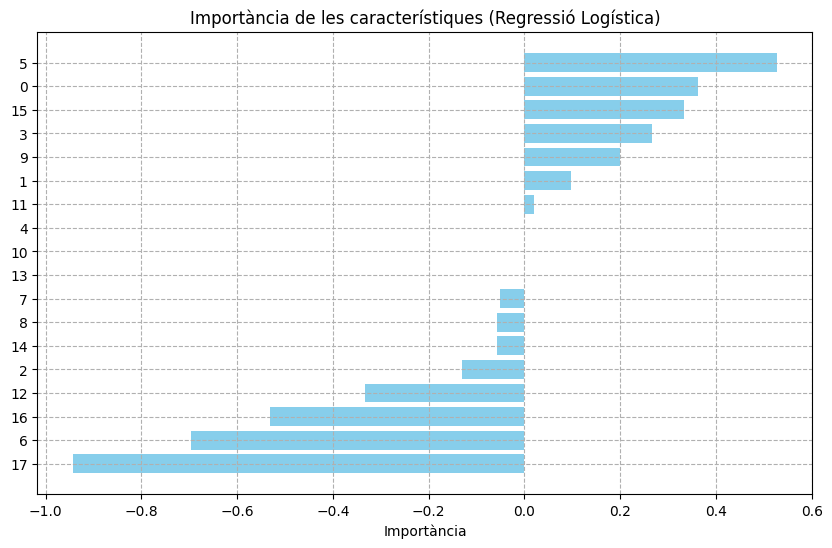

In [37]:
# funció per visualitzar les importàncies
def plot_feature_importance(importancies, title):
    plt.figure(figsize=(10, 6))
    plt.barh(importancies['feature'], importancies['importance'], color='skyblue')
    plt.xlabel('Importància')
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.grid(linestyle='--')
    plt.show()

# visualitzem les importàncies per a cada model
plot_feature_importance(feature_importance_lr, 'Importància de les característiques (Regressió Logística)')

Aquests coeficients, que surten de la taula d'importància de les variables, són els coeficients de la regressió logística. Indiquen com cada variable (feature) contribueix a la predicció del model.

1. **Signe del coeficient**:
   - **Coeficient positiu**: Indica que la variable està directament relacionada amb la probabilitat de la classe positiva (en aquest cas, la contractació d'un dipòsit). És a dir, quan el valor de la variable augmenta, la probabilitat de contractar un dipòsit també augmenta.
   - **Coeficient negatiu**: Indica que la variable està inversament relacionada amb la probabilitat de la classe positiva. Quan el valor de la variable augmenta, la probabilitat de contractar un dipòsit disminueix.

2. **Magnitud del coeficient**:
   - La magnitud absoluta del coeficient indica la importància relativa de la variable. Un coeficient amb una magnitud més gran té un impacte més fort en la predicció.

Els coeficients més importants directament relacionats (coeficient positiu) són els corresponents al CP6, CP1, CP16:

1. **CP6 (+0.528)**  
   - Variables clau (PCA):  
      - `education_tertiary` (+0.523)
      - `education_secondary` (-0.491)
      - `housing` (-0.308)
      - `marital_single` (+0.112)

   - Interpretació:  
      - **Màxim predictor positiu**. Associat a **clients solters amb educació terciària i sense préstec hipotecari**.  
      - Educació superior i estat civil "single" correlacionen amb alta probabilitat de subscripció.  

   - Acció recomanada:  
      - Prioritzar campanyes en **joves universitaris solters sense càrregues hipotecàries**.


2. **CP1 (+0.362)**  
   - Variables clau (PCA):  
      - `pdays` (+0.648)
      - `previous` (+0.637)
      - `poutcome_unknown` (-0.278)

   - Interpretació:  
      - Clients amb **historial d’interaccions prèvies** (més contactes i temps des de l’últim contacte) i **resultats coneguts** de campanyes anteriors.  

   - Acció recomanada:  
      - Enfocar-se en clients amb **participació prèvia en campanyes** i dades completes.


3. **CP16 (+0.333)**  
   - Variables clau (PCA):  
      - `job_admin.` (+0.566)
      - `education_primary` (+0.221)
      - `job_blue-collar` (-0.435)

   - Interpretació:  
      - **Treballadors administratius amb educació primària**, en contrast amb treballadors manuals (`blue-collar`).  

   - Acció recomanada:  
      - Segmentar treballadors administratius amb educació bàsica, oferint productes simples.

Els coeficients més importants inversament relacionats (coeficients negatius) són els corresponents al CP17, CP7, CP18:

1. **CP17 (-0.531)**  
   - Variables clau (PCA):  
      - `job_services` (-0.341)
      - `poutcome_success` (-0.154)

   - Interpretació:  
      - **Predictor negatiu**. Treballadors de serveis amb **èxits en campanyes passades** tendeixen a no subscriure.  

   - Acció recomanada:  
      - Minimitzar inversió en aquest grup. Explorar causes de la seva resistència.


2. **CP7 (-0.695)**  
   - Variables clau (PCA):  
      - `housing` (+0.438)
      - `month_may` (+0.363)
      - `education_secondary` (-0.399) 

   - Interpretació:  
      - Clients amb **préstec hipotecari contactats al maig** i educació secundària.  

   - Acció recomanada:  
      - Evitar campanyes massives al maig per a clients amb hipoteques.


3. **CP18 (-0.943)**  
   - Variables clau (PCA):  
      - `job_services` (+0.516)
      - `education_primary` (+0.267)
      - `poutcome_success` (-0.265)

   - Interpretació:  
      - **Màxim predictor negatiu**. Treballadors de serveis amb **educació primària i sense èxits passats**.  

   - Acció recomanada:  
      - Excloure aquest grup de campanyes estàndard o redissenyar estratègies específiques.


## Conclusions

### 1. Selecció del model òptim
Després d'avaluar tres models (Regressió Logística, Random Forest i Gradient Boosting), **la Regressió Logística s'ha identificat com el model més adequat** per als objectius del negoci, basant-nos en les següents raons:  
- **Recall més alt (0.67)**: És crític per maximitzar la identificació de clients que contractaran un dipòsit, ja que captura el 67% dels clients positius, superant als altres models (Random Forest: 0.64; Gradient Boosting: 0.61).  
- **Simplicitat i interpretabilitat**: A diferència dels models basats en arbres, la Regressió Logística permet una interpretació clara dels coeficients, facilitant la presa de decisions estratègiques.  
- **Rendiment equilibrat**: Tot i tenir una precisió (0.64) i AUC-ROC (0.74) lleugerament inferiors al Random Forest, la diferència no és significativa, i el guany en recall justifica la seva elecció.

### 2. Components principals clau

| Component | Coeficient | Tendència | Grup Clau |  
|-----------|------------|-----------|-----------|  
| **CP6**   | +0.528     | ➚ Alta    | Joves universitaris solters sense préstec hipotecari |  
| **CP1**   | +0.362     | ➚ Moderada| Clients amb historial d’interaccions en campanyes passades i resultats coneguts |  
| **CP16**  | +0.333     | ➚ Baixa   | Treballadors administratius amb educació bàsica |  
| **CP17**  | -0.531     | ➘ Moderada| Treballadors de serveis amb educació primària i sense èxits passats |  
| **CP7**   | -0.695     | ➘ Forta   | Clients amb hipoteca contactats al maig |  
| **CP18**  | -0.943     | ➘ Màxima  | Treballadors de serveis amb èxits passats |  

Aquests components subratllen la importància de variables com l’educació, l’estat civil, el tipus de feina i l’historial de campanyes.  

### 3. Accions estratègiques recomanades
Basant-nos en les interpretacions dels components i el rendiment del model, es proposen les següents accions:  
1. **Prioritzar grups d’alta conversió**:  
   - Enfocar campanyes en **joves universitaris solters (CP6)** i **treballadors administratius amb educació bàsica (CP16)**.  
   - Recontactar clients amb **participació activa en campanyes anteriors (CP1)**.  
2. **Evitar grups de baix rendiment**:  
   - Excloure o limitar inversió en **treballadors de serveis amb educació primària (CP18)** i **clients amb hipoteca contactats al maig (CP7)**.  

### 4. Limitacions i treball futur
- **Limitacions**:  
  - El recall del 67% implica que un 33% dels clients positius no són detectats, cosa que podria requerir mostreig addicional o inclusió de noves variables.  
  - No és el cas, però les dades desbalancejades podrien afectar la precisió.
- **Treball futur**:  
  - Incorporar dades externes (ex.: condició econòmica, tendències de mercat) per millorar els predictors.  
  - Explorar models híbrids que combinin la interpretabilitat de la Regressió Logística amb la potència predictiva del Gradient Boosting.  

### 5. Impacte esperat
Amb la implementació d’aquestes accions, s’espera:  
- **Augment de la taxa de contractació**: Enfocant-se en grups d’alta probabilitat (CP6, CP1, CP16).  
- **Reducció de costos operatius**: Evitant inversions ineficaços en grups resistents (CP7, CP17, CP18).  
- **Decisions més informades**: Gràcies a la interpretabilitat del model i dels components principals.  

Aquest enfocament equilibra l’eficiència operativa amb la maximització de resultats, alineant-se amb els objectius estratègics del negoci. 

In [43]:
# guardem el model de regressió logística
joblib.dump(model_lr_final, 'models/model_lr_final.joblib')

# guardem el model utilitzant pickle
import pickle
with open('models/model_lr_final.pkl', 'wb') as file:
    pickle.dump(model_lr_final, file)